# Phase 7: Trust Score Regression Models

Train ML models with train/validation/test split to detect overfitting and data leakage.

**Models:** Linear Regression, Random Forest, Gradient Boosting, XGBoost

**Metrics:** RMSE, MAE, R², Spearman Correlation

**Overfitting Detection:** Compare performance across all three datasets

In [1]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

## 1. Load & Prepare Data

In [2]:
df = pd.read_csv("../data/processed/trust_scored_dataset.csv")
print(f"Dataset shape: {df.shape}")

feature_cols = [
    'review_length', 'sentiment_score', 'sentiment_extreme', 'repetition_ratio',
    'unique_word_ratio', 'exclamation_count', 'question_count',
    'user_review_count', 'user_rating_variance', 'user_avg_rating_deviation',
    'user_review_frequency', 'user_extreme_ratio', 'user_burst_flag',
    'user_product_diversity', 'product_review_count', 'product_rating_variance',
    'product_rating_std', 'product_popularity_log', 'product_user_diversity',
    'days_since_first_review', 'review_density', 'review_time_gap', 'burst_indicator',
    'rating', 'rating_deviation', 'verified', 'helpful_ratio'
]

available_features = [col for col in feature_cols if col in df.columns]
X = df[available_features].fillna(0)
y = df['trust_score']

print(f"Features: {len(available_features)}")
print(f"Target shape: {y.shape}")

Dataset shape: (719967, 29)
Features: 5
Target shape: (719967,)


## 2. Train/Validation/Test Split (60/20/20)

In [3]:
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42)

print(f"Train: {X_train.shape[0]} ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Val:   {X_val.shape[0]} ({X_val.shape[0]/len(X)*100:.1f}%)")
print(f"Test:  {X_test.shape[0]} ({X_test.shape[0]/len(X)*100:.1f}%)")

Train: 431979 (60.0%)
Val:   143994 (20.0%)
Test:  143994 (20.0%)


## 3. Feature Scaling

In [4]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)
print("Features scaled")

Features scaled


## 4. Evaluation Function

In [5]:
def evaluate_model(y_true, y_pred, model_name, dataset_name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    spearman, _ = spearmanr(y_true, y_pred)
    return {'Model': model_name, 'Dataset': dataset_name, 'RMSE': rmse, 'MAE': mae, 'R2': r2, 'Spearman': spearman}

## 5. Train Models

In [6]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
lr_results = [
    evaluate_model(y_train, lr.predict(X_train_scaled), 'Linear Regression', 'Train'),
    evaluate_model(y_val, lr.predict(X_val_scaled), 'Linear Regression', 'Validation'),
    evaluate_model(y_test, lr.predict(X_test_scaled), 'Linear Regression', 'Test')
]
print("Linear Regression trained")

Linear Regression trained


In [7]:
rf = RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
rf_results = [
    evaluate_model(y_train, rf.predict(X_train), 'Random Forest', 'Train'),
    evaluate_model(y_val, rf.predict(X_val), 'Random Forest', 'Validation'),
    evaluate_model(y_test, rf.predict(X_test), 'Random Forest', 'Test')
]
print("Random Forest trained")

Random Forest trained


In [8]:
gb = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
gb.fit(X_train, y_train)
gb_results = [
    evaluate_model(y_train, gb.predict(X_train), 'Gradient Boosting', 'Train'),
    evaluate_model(y_val, gb.predict(X_val), 'Gradient Boosting', 'Validation'),
    evaluate_model(y_test, gb.predict(X_test), 'Gradient Boosting', 'Test')
]
print("Gradient Boosting trained")

Gradient Boosting trained


In [9]:
xgb = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=6, random_state=42, n_jobs=-1)
xgb.fit(X_train, y_train)
xgb_results = [
    evaluate_model(y_train, xgb.predict(X_train), 'XGBoost', 'Train'),
    evaluate_model(y_val, xgb.predict(X_val), 'XGBoost', 'Validation'),
    evaluate_model(y_test, xgb.predict(X_test), 'XGBoost', 'Test')
]
print("XGBoost trained")

XGBoost trained


## 6. Comprehensive Results

In [10]:
all_results = pd.DataFrame(lr_results + rf_results + gb_results + xgb_results)

print("\n" + "="*100)
print("ALL MODELS - TRAIN/VALIDATION/TEST PERFORMANCE")
print("="*100)
print(all_results.to_string(index=False))
print("="*100)

all_results.to_csv('../results/reports/model_performance_all_datasets.csv', index=False)


ALL MODELS - TRAIN/VALIDATION/TEST PERFORMANCE
            Model    Dataset     RMSE      MAE       R2  Spearman
Linear Regression      Train 0.062141 0.041410 0.740809  0.809302
Linear Regression Validation 0.062255 0.041442 0.741826  0.811256
Linear Regression       Test 0.062214 0.041441 0.740858  0.809671
    Random Forest      Train 0.052329 0.033884 0.816203  0.878472
    Random Forest Validation 0.056430 0.036616 0.787878  0.868228
    Random Forest       Test 0.056400 0.036533 0.787028  0.866858
Gradient Boosting      Train 0.055555 0.036469 0.792837  0.869246
Gradient Boosting Validation 0.055748 0.036599 0.792975  0.870305
Gradient Boosting       Test 0.055771 0.036577 0.791753  0.869445
          XGBoost      Train 0.055495 0.036411 0.793286  0.869287
          XGBoost Validation 0.055764 0.036595 0.792859  0.870220
          XGBoost       Test 0.055767 0.036558 0.791781  0.869381


## 7. Overfitting & Data Leakage Analysis

In [11]:
models = ['Linear Regression', 'Random Forest', 'Gradient Boosting', 'XGBoost']
analysis = []

for model in models:
    m_data = all_results[all_results['Model'] == model]
    train_r2 = m_data[m_data['Dataset'] == 'Train']['R2'].values[0]
    val_r2 = m_data[m_data['Dataset'] == 'Validation']['R2'].values[0]
    test_r2 = m_data[m_data['Dataset'] == 'Test']['R2'].values[0]
    
    train_rmse = m_data[m_data['Dataset'] == 'Train']['RMSE'].values[0]
    val_rmse = m_data[m_data['Dataset'] == 'Validation']['RMSE'].values[0]
    test_rmse = m_data[m_data['Dataset'] == 'Test']['RMSE'].values[0]
    
    train_spear = m_data[m_data['Dataset'] == 'Train']['Spearman'].values[0]
    val_spear = m_data[m_data['Dataset'] == 'Validation']['Spearman'].values[0]
    test_spear = m_data[m_data['Dataset'] == 'Test']['Spearman'].values[0]
    
    r2_gap = train_r2 - test_r2
    rmse_gap = test_rmse - train_rmse
    spear_gap = train_spear - test_spear
    
    analysis.append({
        'Model': model,
        'Train_R2': train_r2, 'Val_R2': val_r2, 'Test_R2': test_r2,
        'R2_Gap': r2_gap,
        'Train_RMSE': train_rmse, 'Val_RMSE': val_rmse, 'Test_RMSE': test_rmse,
        'RMSE_Gap': rmse_gap,
        'Train_Spear': train_spear, 'Val_Spear': val_spear, 'Test_Spear': test_spear,
        'Spear_Gap': spear_gap
    })

analysis_df = pd.DataFrame(analysis)

print("\n" + "="*120)
print("OVERFITTING ANALYSIS - R² METRICS")
print("="*120)
print(analysis_df[['Model', 'Train_R2', 'Val_R2', 'Test_R2', 'R2_Gap']].to_string(index=False))
print("="*120)

print("\n" + "="*120)
print("OVERFITTING ANALYSIS - RMSE METRICS")
print("="*120)
print(analysis_df[['Model', 'Train_RMSE', 'Val_RMSE', 'Test_RMSE', 'RMSE_Gap']].to_string(index=False))
print("="*120)

print("\n" + "="*120)
print("OVERFITTING ANALYSIS - SPEARMAN CORRELATION (Ranking Quality)")
print("="*120)
print(analysis_df[['Model', 'Train_Spear', 'Val_Spear', 'Test_Spear', 'Spear_Gap']].to_string(index=False))
print("="*120)

analysis_df.to_csv('../results/reports/overfitting_analysis.csv', index=False)


OVERFITTING ANALYSIS - R² METRICS
            Model  Train_R2   Val_R2  Test_R2    R2_Gap
Linear Regression  0.740809 0.741826 0.740858 -0.000049
    Random Forest  0.816203 0.787878 0.787028  0.029174
Gradient Boosting  0.792837 0.792975 0.791753  0.001084
          XGBoost  0.793286 0.792859 0.791781  0.001505

OVERFITTING ANALYSIS - RMSE METRICS
            Model  Train_RMSE  Val_RMSE  Test_RMSE  RMSE_Gap
Linear Regression    0.062141  0.062255   0.062214  0.000072
    Random Forest    0.052329  0.056430   0.056400  0.004071
Gradient Boosting    0.055555  0.055748   0.055771  0.000215
          XGBoost    0.055495  0.055764   0.055767  0.000272

OVERFITTING ANALYSIS - SPEARMAN CORRELATION (Ranking Quality)
            Model  Train_Spear  Val_Spear  Test_Spear  Spear_Gap
Linear Regression     0.809302   0.811256    0.809671  -0.000369
    Random Forest     0.878472   0.868228    0.866858   0.011615
Gradient Boosting     0.869246   0.870305    0.869445  -0.000198
          XGBoost   

## 8. Data Leakage & Overfitting Detection

In [12]:
print("\n" + "="*120)
print("DATA LEAKAGE & OVERFITTING DETECTION")
print("="*120)

for idx, row in analysis_df.iterrows():
    print(f"\n{row['Model']}:")
    print("-" * 100)
    
    # Check 1: Validation between train and test
    val_between = (row['Val_R2'] <= row['Train_R2']) and (row['Val_R2'] >= row['Test_R2'])
    print(f"  ✓ Val R² between Train and Test: {val_between}")
    print(f"    Train: {row['Train_R2']:.4f}, Val: {row['Val_R2']:.4f}, Test: {row['Test_R2']:.4f}")
    
    # Check 2: Overfitting (R² gap)
    overfitting = row['R2_Gap'] > 0.05
    print(f"  ✓ Overfitting detected (R² gap > 0.05): {overfitting}")
    print(f"    R² Gap (Train - Test): {row['R2_Gap']:.4f}")
    
    # Check 3: RMSE increases from train to test
    rmse_increase = row['Test_RMSE'] >= row['Train_RMSE']
    print(f"  ✓ RMSE increases Train→Test (expected): {rmse_increase}")
    print(f"    Train: {row['Train_RMSE']:.4f}, Test: {row['Test_RMSE']:.4f}")
    
    # Check 4: Spearman consistency
    spear_consistent = row['Spear_Gap'] < 0.05
    print(f"  ✓ Spearman consistent (gap < 0.05): {spear_consistent}")
    print(f"    Train: {row['Train_Spear']:.4f}, Test: {row['Test_Spear']:.4f}")
    
    # Check 5: Val-Test gap small
    val_test_gap = abs(row['Val_R2'] - row['Test_R2'])
    val_proxy = val_test_gap < 0.03
    print(f"  ✓ Val is good proxy for Test (gap < 0.03): {val_proxy}")
    print(f"    Val-Test R² gap: {val_test_gap:.4f}")
    
    # Overall health
    checks = [val_between, not overfitting, rmse_increase, spear_consistent, val_proxy]
    health = sum(checks) / len(checks) * 100
    print(f"\n  Model Health Score: {health:.0f}% ({sum(checks)}/5 checks passed)")
    
    if health >= 80:
        print(f"  Status: ✅ HEALTHY - No significant issues")
    elif health >= 60:
        print(f"  Status: ⚠️  WARNING - Minor issues detected")
    else:
        print(f"  Status: ❌ CRITICAL - Significant overfitting/leakage")

print("\n" + "="*120)


DATA LEAKAGE & OVERFITTING DETECTION

Linear Regression:
----------------------------------------------------------------------------------------------------
  ✓ Val R² between Train and Test: False
    Train: 0.7408, Val: 0.7418, Test: 0.7409
  ✓ Overfitting detected (R² gap > 0.05): False
    R² Gap (Train - Test): -0.0000
  ✓ RMSE increases Train→Test (expected): True
    Train: 0.0621, Test: 0.0622
  ✓ Spearman consistent (gap < 0.05): True
    Train: 0.8093, Test: 0.8097
  ✓ Val is good proxy for Test (gap < 0.03): True
    Val-Test R² gap: 0.0010

  Model Health Score: 80% (4/5 checks passed)
  Status: ✅ HEALTHY - No significant issues

Random Forest:
----------------------------------------------------------------------------------------------------
  ✓ Val R² between Train and Test: True
    Train: 0.8162, Val: 0.7879, Test: 0.7870
  ✓ Overfitting detected (R² gap > 0.05): False
    R² Gap (Train - Test): 0.0292
  ✓ RMSE increases Train→Test (expected): True
    Train: 0.0523,

## 9. Visualizations

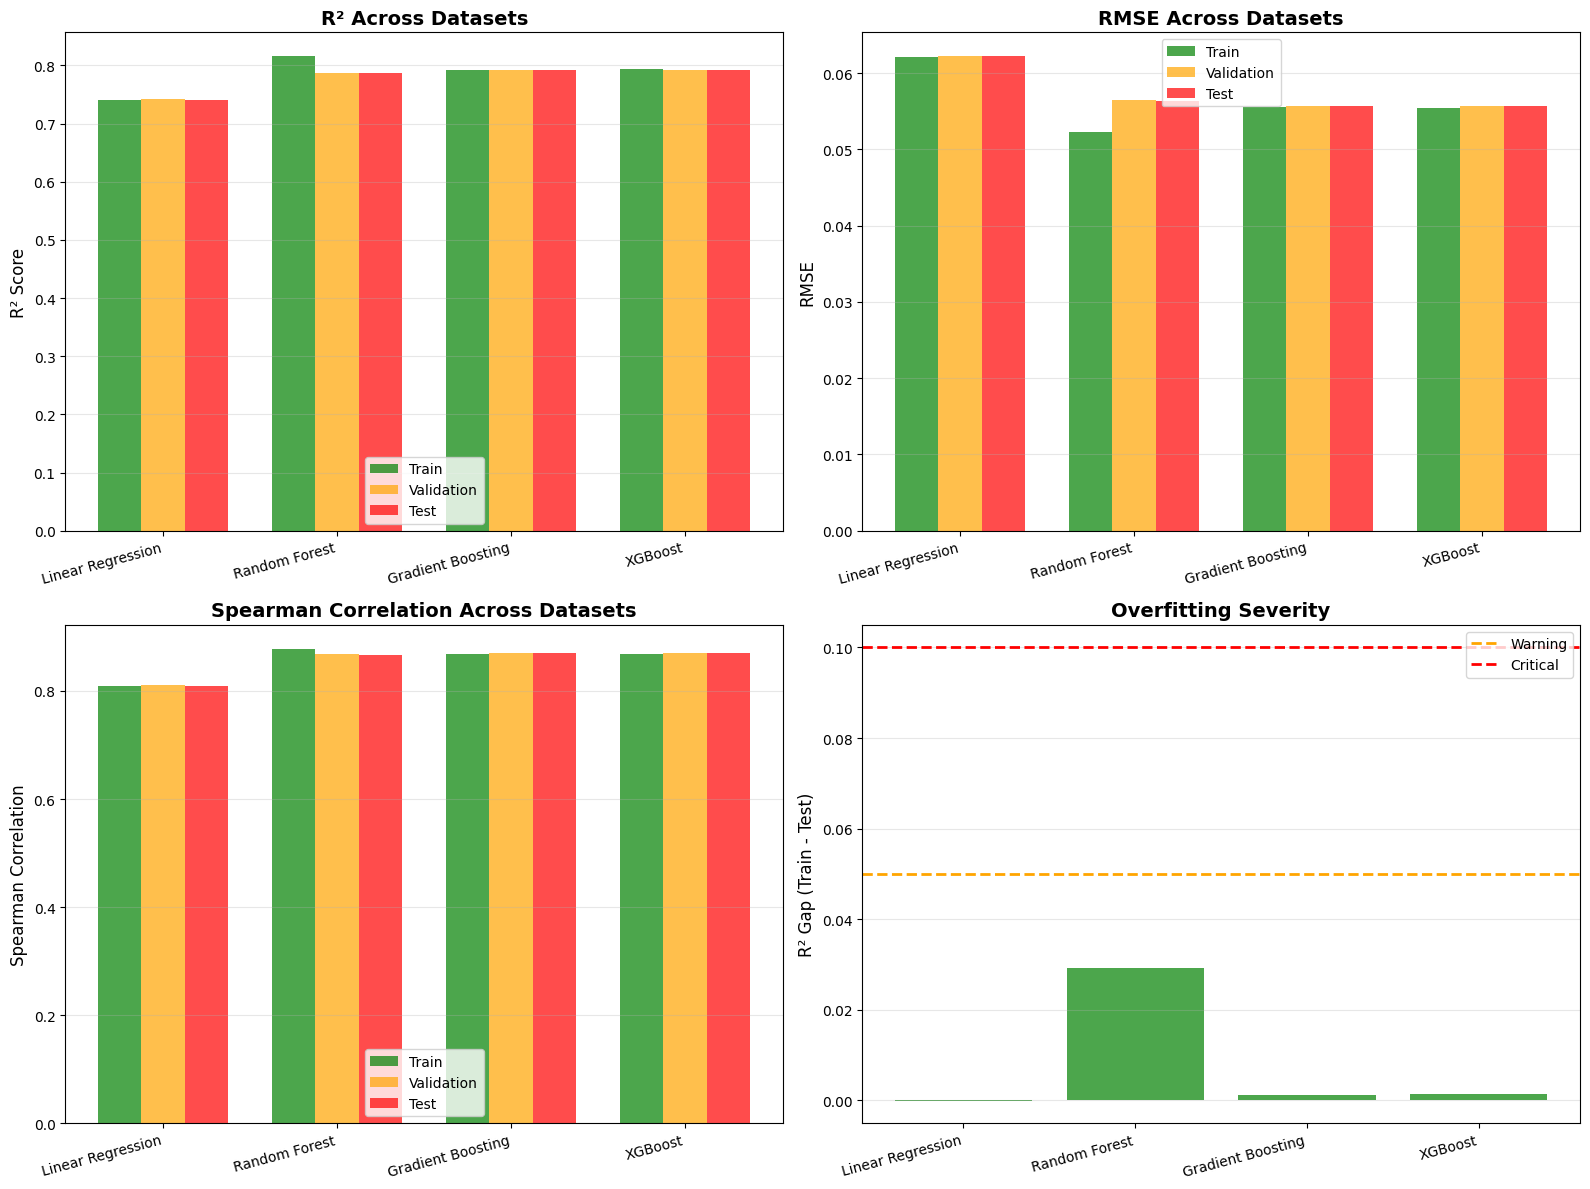

Visualization saved


In [13]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

models_list = analysis_df['Model'].tolist()
x = np.arange(len(models_list))
width = 0.25

# R² comparison
axes[0, 0].bar(x - width, analysis_df['Train_R2'], width, label='Train', color='green', alpha=0.7)
axes[0, 0].bar(x, analysis_df['Val_R2'], width, label='Validation', color='orange', alpha=0.7)
axes[0, 0].bar(x + width, analysis_df['Test_R2'], width, label='Test', color='red', alpha=0.7)
axes[0, 0].set_ylabel('R² Score', fontsize=12)
axes[0, 0].set_title('R² Across Datasets', fontsize=14, fontweight='bold')
axes[0, 0].set_xticks(x)
axes[0, 0].set_xticklabels(models_list, rotation=15, ha='right')
axes[0, 0].legend()
axes[0, 0].grid(axis='y', alpha=0.3)

# RMSE comparison
axes[0, 1].bar(x - width, analysis_df['Train_RMSE'], width, label='Train', color='green', alpha=0.7)
axes[0, 1].bar(x, analysis_df['Val_RMSE'], width, label='Validation', color='orange', alpha=0.7)
axes[0, 1].bar(x + width, analysis_df['Test_RMSE'], width, label='Test', color='red', alpha=0.7)
axes[0, 1].set_ylabel('RMSE', fontsize=12)
axes[0, 1].set_title('RMSE Across Datasets', fontsize=14, fontweight='bold')
axes[0, 1].set_xticks(x)
axes[0, 1].set_xticklabels(models_list, rotation=15, ha='right')
axes[0, 1].legend()
axes[0, 1].grid(axis='y', alpha=0.3)

# Spearman comparison
axes[1, 0].bar(x - width, analysis_df['Train_Spear'], width, label='Train', color='green', alpha=0.7)
axes[1, 0].bar(x, analysis_df['Val_Spear'], width, label='Validation', color='orange', alpha=0.7)
axes[1, 0].bar(x + width, analysis_df['Test_Spear'], width, label='Test', color='red', alpha=0.7)
axes[1, 0].set_ylabel('Spearman Correlation', fontsize=12)
axes[1, 0].set_title('Spearman Correlation Across Datasets', fontsize=14, fontweight='bold')
axes[1, 0].set_xticks(x)
axes[1, 0].set_xticklabels(models_list, rotation=15, ha='right')
axes[1, 0].legend()
axes[1, 0].grid(axis='y', alpha=0.3)

# R² Gap (overfitting severity)
colors = ['green' if x < 0.05 else 'orange' if x < 0.1 else 'red' for x in analysis_df['R2_Gap']]
axes[1, 1].bar(models_list, analysis_df['R2_Gap'], color=colors, alpha=0.7)
axes[1, 1].set_ylabel('R² Gap (Train - Test)', fontsize=12)
axes[1, 1].set_title('Overfitting Severity', fontsize=14, fontweight='bold')
axes[1, 1].set_xticklabels(models_list, rotation=15, ha='right')
axes[1, 1].axhline(y=0.05, color='orange', linestyle='--', linewidth=2, label='Warning')
axes[1, 1].axhline(y=0.1, color='red', linestyle='--', linewidth=2, label='Critical')
axes[1, 1].legend()
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../results/figures/overfitting_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("Visualization saved")

## 10. Save Best Model

In [14]:
# Select best model based on test set Spearman
test_results = all_results[all_results['Dataset'] == 'Test'].sort_values('Spearman', ascending=False)
best_model_name = test_results.iloc[0]['Model']

if best_model_name == 'XGBoost':
    best_model = xgb
elif best_model_name == 'Random Forest':
    best_model = rf
elif best_model_name == 'Gradient Boosting':
    best_model = gb
else:
    best_model = lr

joblib.dump(best_model, '../models/trained/best_trust_model.pkl')
joblib.dump(scaler, '../models/feature_scaler.pkl')

with open('../models/trained/feature_names.txt', 'w') as f:
    f.write('\n'.join(available_features))

print(f"Best model: {best_model_name}")
print(f"Test Spearman: {test_results.iloc[0]['Spearman']:.4f}")
print("Model saved")

Best model: Gradient Boosting
Test Spearman: 0.8694
Model saved


## Summary

**Phase 7 Complete:**
- Trained 4 models with train/validation/test split
- Comprehensive overfitting analysis across all datasets
- Data leakage detection through validation consistency
- Best model selected based on test set performance
- All metrics saved for Phase 8 aggregation